# Arsenic contamination event detection

This notebook shows the Torch-based detector in `src/event_detection.py`, then sweeps a few network shapes to compare precision and recall on the SCADA data.

The goal here is not only to detect events, but also to make the detector stricter when needed, which typically means higher precision and lower recall.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.event_detection import build_detector, collect_default_data_paths, split_train_test

data_dir = ROOT / 'src' / 'data'
paths = collect_default_data_paths(data_dir)
train_paths, test_paths = split_train_test(paths)

print(f'Loaded {len(paths)} SCADA files')
print(f'Train files: {len(train_paths)} | Test files: {len(test_paths)}')

Loaded 20 SCADA files
Train files: 14 | Test files: 6


In [2]:
history = 5
epochs = 12
batch_size = 256
learning_rate = 1e-3

baseline_hidden_sizes = (128, 64)
detector = build_detector(
    train_paths,
    history=history,
    epochs=epochs,
    batch_size=batch_size,
    learning_rate=learning_rate,
    hidden_sizes=baseline_hidden_sizes,
)

train_results = [detector.detect(path) for path in train_paths[:3]]
test_results = [detector.detect(path) for path in test_paths[:3]]

train_summary = pd.DataFrame([result.summary() for result in train_results]).mean(numeric_only=True)
test_summary = pd.DataFrame([result.summary() for result in test_results]).mean(numeric_only=True)

print('Device:', detector.device)
print('Baseline hidden sizes:', baseline_hidden_sizes)
print('Train summary:')
display(train_summary.to_frame('value'))
print('Test summary:')
display(test_summary.to_frame('value'))

Device: mps
Baseline hidden sizes: (128, 64)
Train summary:


,value
precision,0.352803
accuracy,0.931275
probability_of_detection,0.333333
recall,0.333333
false_alarm_rate,0.038045
detection_latency_seconds,-230400.000000
alarms,52.666667


Test summary:


,value
precision,0.337165
accuracy,0.936587
probability_of_detection,0.312925
recall,0.312925
false_alarm_rate,0.031414
detection_latency_seconds,-161400.000000
alarms,45.333333


## Shape sweep

The detector uses a small feed-forward ANN over lagged chlorine, flow, and arsenic values. A narrower network tends to be less expressive and can miss short anomalies; a wider network usually catches more events but can also raise false alarms.

The sweep below compares a few shapes and lets you pick the one that best matches the precision/recall trade-off you want. If you want a stricter detector, choose the model with higher precision and lower recall.

In [3]:
candidate_shapes = [
    (32,),
    (64, 32),
    (128, 64),
    (128, 64, 32),
]

shape_rows = []
for hidden_sizes in candidate_shapes:
    candidate_detector = build_detector(
        train_paths,
        history=history,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
        hidden_sizes=hidden_sizes,
    )
    candidate_results = [candidate_detector.detect(path) for path in test_paths[:3]]
    candidate_summaries = [result.summary() for result in candidate_results]

    latency_values = [
        summary.get('detection_latency_seconds', np.nan)
        for summary in candidate_summaries
        if np.isfinite(summary.get('detection_latency_seconds', np.nan))
    ]

    shape_rows.append({
        'hidden_sizes': hidden_sizes,
        'accuracy': float(np.mean([summary.get('accuracy', 0.0) for summary in candidate_summaries])),
        'precision': float(np.mean([summary.get('precision', 0.0) for summary in candidate_summaries])),
        'probability_of_detection': float(np.mean([
            summary.get('probability_of_detection', summary.get('recall', 0.0))
            for summary in candidate_summaries
        ])),
        'false_alarm_rate': float(np.mean([summary.get('false_alarm_rate', 0.0) for summary in candidate_summaries])),
        'detection_latency_seconds': float(np.mean(latency_values)) if latency_values else np.nan,
        'alarms': float(np.mean([summary.get('alarms', 0.0) for summary in candidate_summaries])),
    })

shape_df = pd.DataFrame(shape_rows).sort_values(['precision', 'probability_of_detection'], ascending=[False, True]).reset_index(drop=True)
shape_df

,hidden_sizes,accuracy,precision,probability_of_detection,false_alarm_rate,detection_latency_seconds,alarms
0,"(32,)",0.921315,0.232517,0.251701,0.044328,-260400.0,54.666667
1,"(128, 64)",0.790173,0.155789,0.748299,0.207679,-225600.0,235.000000
2,"(64, 32)",0.716135,0.116057,0.721088,0.284119,-241200.0,306.666667
3,"(128, 64, 32)",0.525232,0.064469,0.646259,0.480977,-260400.0,491.000000


## Plot the chosen detector

The plot shows the residual, dynamic thresholds, and event probability for one test file. Alarm spikes should line up with the contamination window and stay relatively sparse if the detector is tuned to be stricter.

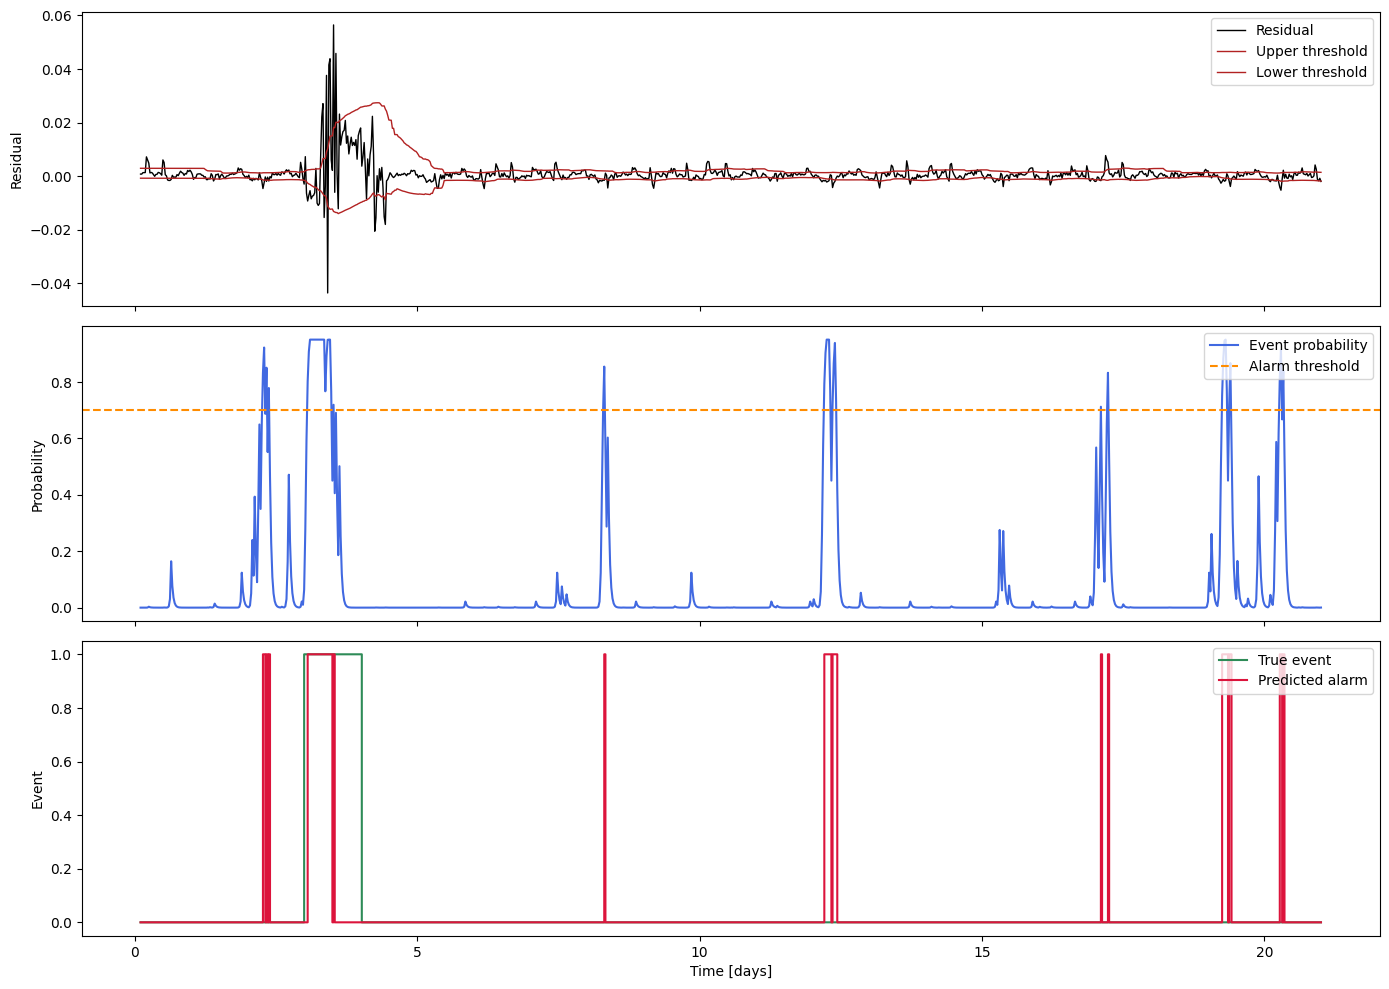

Chosen shape: (32,)
{'precision': 0.4489795918367347, 'accuracy': 0.9462151394422311, 'probability_of_detection': 0.4489795918367347, 'recall': 0.4489795918367347, 'false_alarm_rate': 0.028272251308900525, 'detection_latency_seconds': -81000.0, 'alarms': 49}


In [4]:
best_hidden_sizes = tuple(shape_df.iloc[0]['hidden_sizes'])
best_detector = build_detector(
    train_paths,
    history=history,
    epochs=epochs,
    batch_size=batch_size,
    learning_rate=learning_rate,
    hidden_sizes=best_hidden_sizes,
)

sample_result = best_detector.detect(test_paths[0])
sample_days = sample_result.times / 86400.0

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(sample_days, sample_result.residuals, color='black', linewidth=1, label='Residual')
axes[0].plot(sample_days, sample_result.upper_threshold, color='firebrick', linewidth=1, label='Upper threshold')
axes[0].plot(sample_days, sample_result.lower_threshold, color='firebrick', linewidth=1, label='Lower threshold')
axes[0].set_ylabel('Residual')
axes[0].legend(loc='upper right')

axes[1].plot(sample_days, sample_result.event_probability, color='royalblue', linewidth=1.5, label='Event probability')
axes[1].axhline(best_detector.threshold.alarm_threshold, color='darkorange', linestyle='--', label='Alarm threshold')
axes[1].set_ylabel('Probability')
axes[1].legend(loc='upper right')

axes[2].step(sample_days, sample_result.event_flags.astype(int), where='post', color='seagreen', label='True event')
axes[2].step(sample_days, sample_result.alarms.astype(int), where='post', color='crimson', label='Predicted alarm')
axes[2].set_ylabel('Event')
axes[2].set_xlabel('Time [days]')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

print('Chosen shape:', best_hidden_sizes)
print(sample_result.summary())